# Setup

In [4]:
pip install mlflow dagshub imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 91.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, precision_recall_curve,
                             f1_score, precision_score, recall_score)
from sklearn.feature_selection import SelectFromModel
from imblearn.under_sampling import RandomUnderSampler

In [6]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import dagshub

dagshub.init(repo_owner='adzid23', repo_name='Freeuni_ML_Fraud_Detection', mlflow=True)
mlflow.set_experiment("XGBoost_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a940b703-434d-4e27-89d5-f9f47c555d4f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d0663188f23b95990eb4644003cd44222db1a541c69f61014e65ad2d9da28a9c




Accessing as adzid23

Initialized MLflow to track repo "adzid23/Freeuni_ML_Fraud_Detection"

Repository adzid23/Freeuni_ML_Fraud_Detection initialized!

2026/05/05 10:24:31 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/d88ca01f55a64d9899185018d745ee49', creation_time=1777976671712, experiment_id='5', last_update_time=1777976671712, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

# Data Loading

In [17]:
DATA_PATH = '/kaggle/input/competitions/ieee-fraud-detection'

train_transaction = pd.read_csv(f'{DATA_PATH}/train_transaction.csv')
train_identity    = pd.read_csv(f'{DATA_PATH}/train_identity.csv')

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID'])

print(f"Shape after merge: {df.shape}")
print(f"Fraud rate: {y.mean():.4f}")

Shape after merge: (590540, 434)
Fraud rate: 0.0350


# EDA

## Class Imbalance

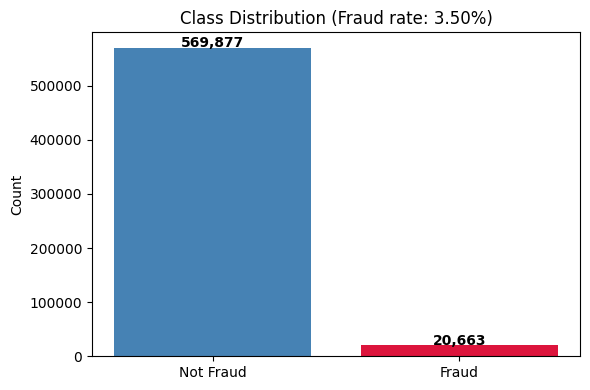

Not Fraud: 569,877 (96.50%)
Fraud:     20,663 (3.50%)
Imbalance ratio: 27.6:1


In [18]:
fraud_counts = y.value_counts()
fraud_rate   = y.mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title(f'Class Distribution (Fraud rate: {fraud_rate:.2f}%)')
ax.set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Not Fraud: {fraud_counts[0]:,} ({100 - fraud_rate:.2f}%)")
print(f"Fraud:     {fraud_counts[1]:,} ({fraud_rate:.2f}%)")
print(f"Imbalance ratio: {fraud_counts[0] / fraud_counts[1]:.1f}:1")

## TransactionAmt Distribution

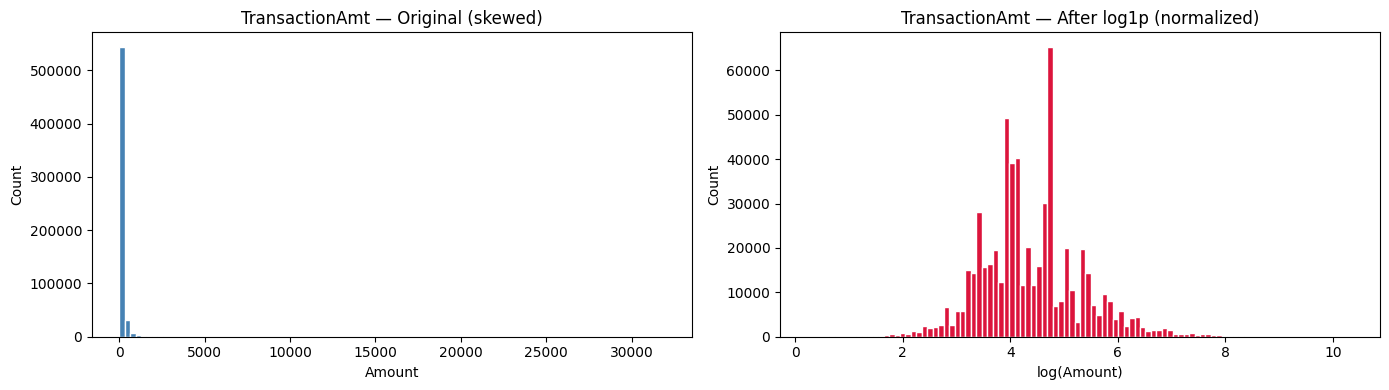

Original — mean: 135.03, std: 239.16
Log      — mean: 4.38, std: 0.94


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['TransactionAmt'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('TransactionAmt — Original (skewed)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['TransactionAmt']), bins=100, color='crimson', edgecolor='white')
axes[1].set_title('TransactionAmt — After log1p (normalized)')
axes[1].set_xlabel('log(Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Original — mean: {df['TransactionAmt'].mean():.2f}, std: {df['TransactionAmt'].std():.2f}")
print(f"Log      — mean: {np.log1p(df['TransactionAmt']).mean():.2f}, std: {np.log1p(df['TransactionAmt']).std():.2f}")

## Missing Values

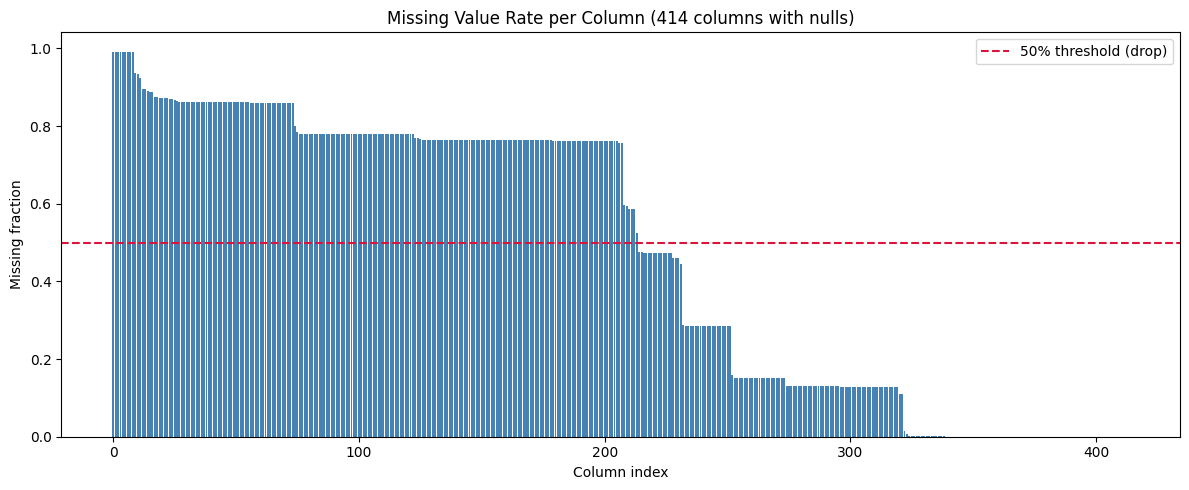

Columns with any nulls:    414
Columns above 50% null:    214
Columns above 90% null:    12


In [20]:
null_frac = X.isnull().mean().sort_values(ascending=False)
null_frac = null_frac[null_frac > 0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(null_frac)), null_frac.values, color='steelblue')
ax.axhline(y=0.5, color='crimson', linestyle='--', label='50% threshold (drop)')
ax.set_title(f'Missing Value Rate per Column ({len(null_frac)} columns with nulls)')
ax.set_xlabel('Column index')
ax.set_ylabel('Missing fraction')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Columns with any nulls:    {len(null_frac)}")
print(f"Columns above 50% null:    {(null_frac > 0.5).sum()}")
print(f"Columns above 90% null:    {(null_frac > 0.9).sum()}")

## Fraud Rate by Key Features

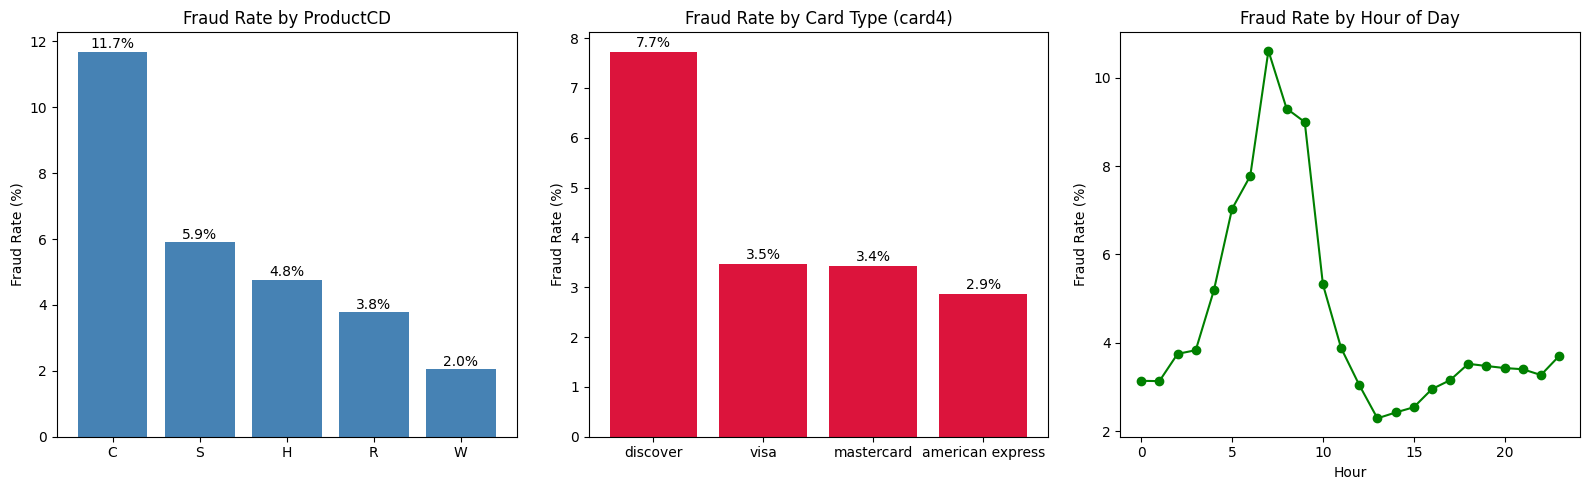

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

productcd_fraud = df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
axes[0].bar(productcd_fraud.index, productcd_fraud.values * 100, color='steelblue')
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(productcd_fraud.values):
    axes[0].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

card4_fraud = df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)
axes[1].bar(card4_fraud.index, card4_fraud.values * 100, color='crimson')
axes[1].set_title('Fraud Rate by Card Type (card4)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(card4_fraud.values):
    axes[1].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

df['hour'] = (df['TransactionDT'] // 3600) % 24
hour_fraud = df.groupby('hour')['isFraud'].mean()
axes[2].plot(hour_fraud.index, hour_fraud.values * 100, 'o-', color='green')
axes[2].set_title('Fraud Rate by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## Top Feature Correlations with Target

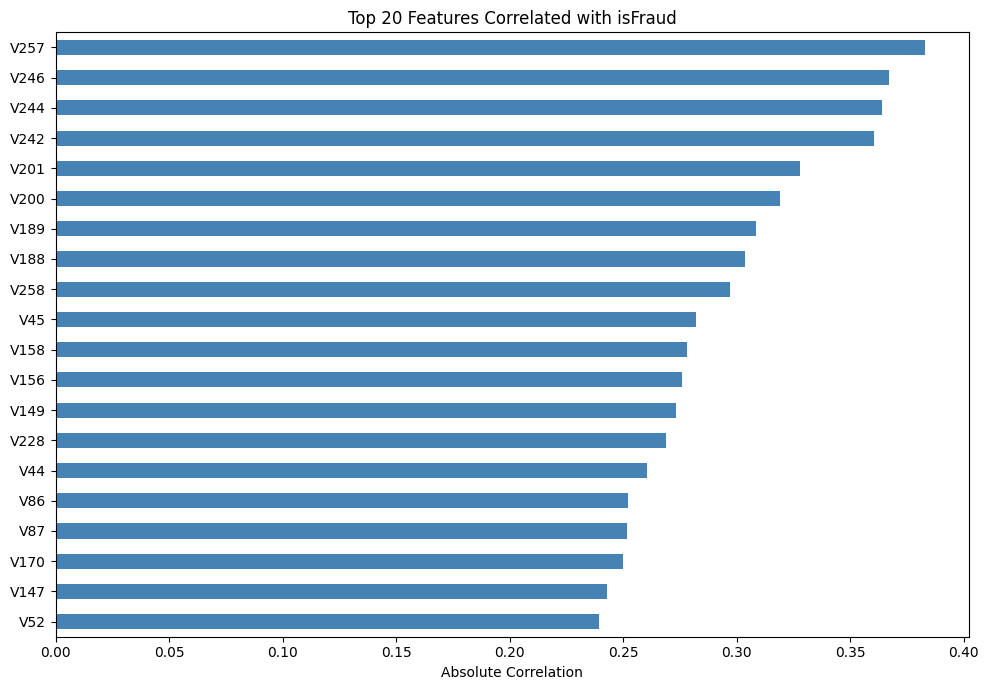

Top 10 correlated features:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
Name: isFraud, dtype: float64


In [22]:
correlations = df.select_dtypes(include=[np.number]).corr()['isFraud'].drop('isFraud')
correlations = correlations.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
correlations.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features Correlated with isFraud')
ax.set_xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
print(correlations.head(10))

# Cleaning

In [23]:
with mlflow.start_run(run_name="XGBoost_Cleaning"):

    null_frac    = X.isnull().mean()
    cols_to_drop = null_frac[null_frac > 0.5].index.tolist()
    X = X.drop(columns=cols_to_drop)
    X = X.drop(columns=['TransactionDT'], errors='ignore')

    num_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
    const_cols   = [c for c in num_cols if X[c].std() < 0.01]
    X = X.drop(columns=const_cols)

    print(f"Dropped {len(cols_to_drop)} high-null columns")
    print(f"Dropped {len(const_cols)} near-constant columns")
    print(f"Shape after cleaning: {X.shape}")

    mlflow.log_params({
        "null_threshold":    0.5,
        "variance_threshold": 0.01,
        "dropped_high_null": len(cols_to_drop),
        "dropped_constant":  len(const_cols),
    })
    mlflow.log_metric("cols_after_cleaning", X.shape[1])

Dropped 214 high-null columns
Dropped 2 near-constant columns
Shape after cleaning: (590540, 215)
🏃 View run XGBoost_Cleaning at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/ccf136de013d4468a7613c47fed0197c
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


# Feature Engineering

In [24]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):

    X['hour']          = (df['TransactionDT'] // 3600) % 24
    X['day']           = (df['TransactionDT'] // (3600 * 24)) % 7
    X['is_night']      = ((X['hour'] >= 0) & (X['hour'] <= 6)).astype(int)
    X['is_weekend']    = (X['day'] >= 5).astype(int)

    X['TransactionAmt_log']     = np.log1p(df['TransactionAmt'])
    X['TransactionAmt_cents']   = (df['TransactionAmt'] * 100).astype(int) % 100
    X['TransactionAmt_isround'] = (df['TransactionAmt'] % 1 == 0).astype(int)

    X['P_email_domain'] = df['P_emaildomain'].apply(
        lambda x: str(x).split('.')[-1] if pd.notna(x) else 'unknown')
    X['is_gmail']    = (df['P_emaildomain'] == 'gmail.com').astype(int)
    X['is_yahoo']    = df['P_emaildomain'].str.contains('yahoo', na=False).astype(int)
    X['same_email']  = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        freq_map = X[col].value_counts(normalize=True).to_dict()
        X[col]   = X[col].map(freq_map).fillna(0)

    card1_stats          = X.groupby('card1')['TransactionAmt'].agg(['mean', 'std']).reset_index()
    card1_stats.columns  = ['card1', 'card1_amt_mean', 'card1_amt_std']
    X = X.merge(card1_stats, on='card1', how='left')

    card2_stats          = X.groupby('card2')['TransactionAmt'].agg(['mean', 'std']).reset_index()
    card2_stats.columns  = ['card2', 'card2_amt_mean', 'card2_amt_std']
    X = X.merge(card2_stats, on='card2', how='left')

    X['card1_amt_diff']  = X['TransactionAmt'] - X['card1_amt_mean']
    X['card1_amt_ratio'] = X['TransactionAmt'] / (X['card1_amt_mean'] + 1e-8)

    X['product_card4_freq'] = (df['ProductCD'].astype(str) + '_' +
                               df['card4'].astype(str))
    prod_freq_map           = X['product_card4_freq'].value_counts(normalize=True).to_dict()
    X['product_card4_freq'] = X['product_card4_freq'].map(prod_freq_map).fillna(0)

    print(f"Shape after feature engineering: {X.shape}")

    mlflow.log_params({
        "time_features":         "hour, day, is_night, is_weekend",
        "amount_features":       "log, cents, isround",
        "email_features":        "is_gmail, is_yahoo, same_email",
        "cat_encoding":          "frequency",
        "aggregation_features":  "card1/card2 mean, std, diff, ratio",
        "interaction_features":  "product_card4_freq"
    })
    mlflow.log_metric("total_features", X.shape[1])

Shape after feature engineering: (590540, 233)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/8a638271ab2c4acbbcf924204e864e37
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


# Feature Selection

Dropped 178 highly correlated columns
Selected 28 features via XGBoost importance
Final feature count: 28


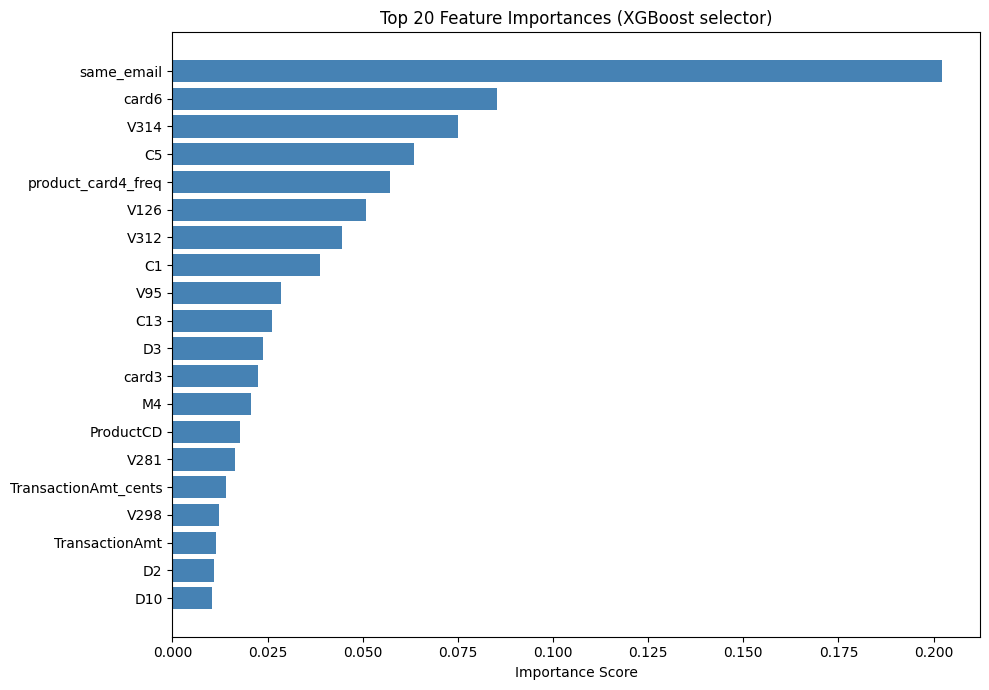

🏃 View run XGBoost_Feature_Selection_v2 at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/130fe1ec22754a1084c73594cc36c887
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


In [25]:
with mlflow.start_run(run_name="XGBoost_Feature_Selection_v2"):

    X_for_corr = X.fillna(-999)
    corr_matrix    = X_for_corr.corr().abs()
    upper          = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.9)]
    X = X.drop(columns=high_corr_cols)
    print(f"Dropped {len(high_corr_cols)} highly correlated columns")

    X_filled = X.fillna(-999)
    selector = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        scale_pos_weight=len(y[y==0]) / len(y[y==1]),
        random_state=42,
        eval_metric='auc',
        tree_method='hist'
    )
    selector.fit(X_filled, y)

    sfm           = SelectFromModel(selector, threshold='median', prefit=True)
    selected_mask = sfm.get_support()
    selected_features = X.columns[selected_mask].tolist()
    X = X[selected_features]

    print(f"Selected {len(selected_features)} features via XGBoost importance")
    print(f"Final feature count: {X.shape[1]}")

    importances = pd.Series(selector.feature_importances_,
                            index=X_filled.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 7))
    top20 = importances.head(20)
    ax.barh(range(len(top20)), top20.values, color='steelblue')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index)
    ax.invert_yaxis()
    ax.set_title('Top 20 Feature Importances (XGBoost selector)')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    mlflow.log_params({
        "correlation_threshold": 0.9,
        "selection_method":      "XGBoost SelectFromModel",
        "importance_threshold":  "median",
    })
    mlflow.log_metric("dropped_high_corr", len(high_corr_cols))
    mlflow.log_metric("features_selected", len(selected_features))

# Training

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (472432, 28) | Test: (118108, 28)


## Run 1 - Baseline XGBoost

In [27]:
with mlflow.start_run(run_name="XGBoost_Baseline"):

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
            eval_metric='auc',
            tree_method='hist',
            random_state=42
        ))
    ])

    pipeline.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  pipeline.predict_proba(X_test)[:, 1])
    gap       = train_auc - test_auc

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {gap:.4f}")

    mlflow.log_params({
        "n_estimators":     100,
        "max_depth":        6,
        "learning_rate":    0.1,
        "scale_pos_weight": round(len(y_train[y_train==0]) / len(y_train[y_train==1]), 2),
        "imbalance_method": "scale_pos_weight"
    })
    mlflow.log_metric("train_auc",    train_auc)
    mlflow.log_metric("test_auc",     test_auc)
    mlflow.log_metric("overfit_gap",  gap)

Train AUC: 0.9299
Test  AUC: 0.9170
Gap:       0.0128
🏃 View run XGBoost_Baseline at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/71d942e117c34e7b8aab0f89c3b6d93c
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


## Run 2 - Imbalance Handling Comparison

In [28]:
with mlflow.start_run(run_name="XGBoost_RandomUnderSampler"):

    rus = RandomUnderSampler(sampling_strategy=0.3, random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train.fillna(-999), y_train)

    print(f"Before resampling: {y_train.value_counts().to_dict()}")
    print(f"After resampling:  {pd.Series(y_resampled).value_counts().to_dict()}")

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='auc',
        tree_method='hist',
        random_state=42
    )

    model.fit(X_resampled, y_resampled)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train.fillna(-999))[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test.fillna(-999))[:, 1])
    gap       = train_auc - test_auc

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {gap:.4f}")

    mlflow.log_params({
        "n_estimators":       100,
        "max_depth":          6,
        "learning_rate":      0.1,
        "imbalance_method":   "RandomUnderSampler",
        "sampling_strategy":  0.3
    })
    mlflow.log_metric("train_auc",   train_auc)
    mlflow.log_metric("test_auc",    test_auc)
    mlflow.log_metric("overfit_gap", gap)

Before resampling: {0: 455902, 1: 16530}
After resampling:  {0: 55100, 1: 16530}
Train AUC: 0.9259
Test  AUC: 0.9150
Gap:       0.0109
🏃 View run XGBoost_RandomUnderSampler at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/05b8b13e2ce7426f9a9767e656b1c781
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


## Run 3 - Early Stopping

In [29]:
with mlflow.start_run(run_name="XGBoost_EarlyStopping"):

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train.fillna(-999), y_train,
        test_size=0.2, random_state=42, stratify=y_train
    )

    model = XGBClassifier(
        n_estimators=1000,     
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric='auc',
        tree_method='hist',
        random_state=42,
        early_stopping_rounds=20  
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    best_iteration = model.best_iteration
    train_auc      = roc_auc_score(y_train, model.predict_proba(X_train.fillna(-999))[:, 1])
    test_auc       = roc_auc_score(y_test,  model.predict_proba(X_test.fillna(-999))[:, 1])
    gap            = train_auc - test_auc

    print(f"Best iteration (early stopping): {best_iteration}")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {gap:.4f}")

    mlflow.log_params({
        "max_n_estimators":     1000,
        "early_stopping_rounds": 20,
        "best_iteration":        best_iteration,
        "imbalance_method":     "scale_pos_weight"
    })
    mlflow.log_metric("train_auc",    train_auc)
    mlflow.log_metric("test_auc",     test_auc)
    mlflow.log_metric("overfit_gap",  gap)

Best iteration (early stopping): 764
Train AUC: 0.9773
Test  AUC: 0.9439
Gap:       0.0334
🏃 View run XGBoost_EarlyStopping at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/24f4122c784841e395d57a2f37c36ba7
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


## Run 4 - Hyperparameter sweep

In [30]:
with mlflow.start_run(run_name="XGBoost_HyperparamSweep"):

    scale_pos = len(y_train[y_train==0]) / len(y_train[y_train==1])
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train.fillna(-999), y_train,
        test_size=0.2, random_state=42, stratify=y_train
    )

    results = []
    for lr in [0.01, 0.05, 0.1]:
        for depth in [4, 6, 8]:

            model = XGBClassifier(
                n_estimators=1000,
                max_depth=depth,
                learning_rate=lr,
                scale_pos_weight=scale_pos,
                eval_metric='auc',
                tree_method='hist',
                random_state=42,
                early_stopping_rounds=20
            )

            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            test_auc = roc_auc_score(y_test, model.predict_proba(X_test.fillna(-999))[:, 1])
            results.append({'lr': lr, 'depth': depth,
                            'best_iter': model.best_iteration, 'test_auc': test_auc})

            mlflow.log_metric(f"lr{lr}_depth{depth}_auc", test_auc)
            print(f"lr={lr} depth={depth} | best_iter={model.best_iteration:>4} | test_auc={test_auc:.4f}")

    best = max(results, key=lambda x: x['test_auc'])
    print(f"\nBest combination: lr={best['lr']}, depth={best['depth']}, AUC={best['test_auc']:.4f}")

lr=0.01 depth=4 | best_iter= 999 | test_auc=0.8947
lr=0.01 depth=6 | best_iter= 999 | test_auc=0.9159
lr=0.01 depth=8 | best_iter= 998 | test_auc=0.9311
lr=0.05 depth=4 | best_iter= 999 | test_auc=0.9257
lr=0.05 depth=6 | best_iter= 998 | test_auc=0.9415
lr=0.05 depth=8 | best_iter= 639 | test_auc=0.9453
lr=0.1 depth=4 | best_iter= 999 | test_auc=0.9362
lr=0.1 depth=6 | best_iter= 764 | test_auc=0.9439
lr=0.1 depth=8 | best_iter= 421 | test_auc=0.9448

Best combination: lr=0.05, depth=8, AUC=0.9453
🏃 View run XGBoost_HyperparamSweep at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/80332a4aeac7476493ca821c7ff852ee
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5


## Run 5 - Threshold Tuning

In [32]:
with mlflow.start_run(run_name="XGBoost_ThresholdTuning_v2"):

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train.fillna(-999), y_train,
        test_size=0.2, random_state=42, stratify=y_train
    )

    scale_pos = len(y_train[y_train==0]) / len(y_train[y_train==1])
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.05,
        scale_pos_weight=scale_pos,
        eval_metric='auc',
        tree_method='hist',
        random_state=42,
        early_stopping_rounds=20
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    y_proba = model.predict_proba(X_test.fillna(-999))[:, 1]

    y_pred_default = (y_proba >= 0.5).astype(int)
    print("=== Default Threshold (0.5) ===")
    print(classification_report(y_test, y_pred_default))

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx  = np.argmax(f1_scores[:-1]) 
    optimal_threshold = thresholds[best_idx]

    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
    print(f"=== Optimal Threshold ({optimal_threshold:.4f}) — Best F1 ===")
    print(classification_report(y_test, y_pred_optimal))

    test_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_params({
        "default_threshold": 0.5,
        "optimal_threshold": round(float(optimal_threshold), 4),
        "threshold_method":  "maximize F1"
    })
    mlflow.log_metric("test_auc",          test_auc)
    mlflow.log_metric("optimal_threshold", float(optimal_threshold))
    mlflow.log_metric("best_f1",           float(f1_scores[best_idx]))

    print(f"\nTest AUC: {test_auc:.4f}")
    print(f"Optimal threshold: {optimal_threshold:.4f}")

=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.97    113975
           1       0.33      0.80      0.47      4133

    accuracy                           0.94    118108
   macro avg       0.66      0.87      0.72    118108
weighted avg       0.97      0.94      0.95    118108

=== Optimal Threshold (0.8390) — Best F1 ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.73      0.59      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.79      0.82    118108
weighted avg       0.98      0.98      0.98    118108


Test AUC: 0.9453
Optimal threshold: 0.8390
🏃 View run XGBoost_ThresholdTuning_v2 at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/97fd134922cf4d139b87210bec956599
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_

## Final Model - CV & Model Registry

In [33]:
with mlflow.start_run(run_name="XGBoost_FinalModel"):

    scale_pos = len(y_train[y_train==0]) / len(y_train[y_train==1])
    skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_aucs      = []
    cv_f1s       = []
    cv_precisions= []
    cv_recalls   = []

    X_filled      = X_train.fillna(-999)
    X_test_filled = X_test.fillna(-999)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_filled, y_train)):
        X_tr, X_val = X_filled.iloc[tr_idx], X_filled.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = XGBClassifier(
            n_estimators=1000,
            max_depth=8,
            learning_rate=0.05,
            scale_pos_weight=scale_pos,
            eval_metric='auc',
            tree_method='hist',
            random_state=42,
            early_stopping_rounds=20
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        val_proba = model.predict_proba(X_val)[:, 1]
        val_pred  = (val_proba >= 0.5).astype(int)

        cv_aucs.append(roc_auc_score(y_val, val_proba))
        cv_f1s.append(f1_score(y_val, val_pred))
        cv_precisions.append(precision_score(y_val, val_pred))
        cv_recalls.append(recall_score(y_val, val_pred))

        mlflow.log_metric("fold_auc", cv_aucs[-1], step=fold)
        print(f"Fold {fold+1}: AUC={cv_aucs[-1]:.4f}  F1={cv_f1s[-1]:.4f}")

    print(f"\nCV AUC:  {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
    print(f"CV F1:   {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")

    final_model = XGBClassifier(
        n_estimators=639,       
        max_depth=8,
        learning_rate=0.05,
        scale_pos_weight=scale_pos,
        eval_metric='auc',
        tree_method='hist',
        random_state=42
    )
    final_model.fit(X_filled, y_train)

    train_auc = roc_auc_score(y_train, final_model.predict_proba(X_filled)[:, 1])
    test_auc  = roc_auc_score(y_test,  final_model.predict_proba(X_test_filled)[:, 1])

    print(f"\nFinal Train AUC: {train_auc:.4f}")
    print(f"Final Test AUC:  {test_auc:.4f}")
    print(f"Gap:             {(train_auc - test_auc):.4f}")

    mlflow.log_params({
        "n_estimators":     639,
        "max_depth":        8,
        "learning_rate":    0.05,
        "scale_pos_weight": round(scale_pos, 2),
        "cv_folds":         5,
        "optimal_threshold": 0.839
    })
    mlflow.log_metric("cv_auc_mean",       np.mean(cv_aucs))
    mlflow.log_metric("cv_auc_std",        np.std(cv_aucs))
    mlflow.log_metric("cv_f1_mean",        np.mean(cv_f1s))
    mlflow.log_metric("cv_precision_mean", np.mean(cv_precisions))
    mlflow.log_metric("cv_recall_mean",    np.mean(cv_recalls))
    mlflow.log_metric("train_auc",         train_auc)
    mlflow.log_metric("test_auc",          test_auc)
    mlflow.log_metric("overfit_gap",       train_auc - test_auc)

    final_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   final_model)
    ])
    final_pipeline.fit(X_train, y_train)

    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="xgboost_fraud_pipeline",
        registered_model_name="XGBoost_Fraud_Pipeline"
    )
    print("Model saved to Model Registry as XGBoost_Fraud_Pipeline")

Fold 1: AUC=0.9415  F1=0.4730
Fold 2: AUC=0.9434  F1=0.5099
Fold 3: AUC=0.9445  F1=0.4879
Fold 4: AUC=0.9432  F1=0.4965
Fold 5: AUC=0.9498  F1=0.4917

CV AUC:  0.9445 ± 0.0028
CV F1:   0.4918 ± 0.0120

Final Train AUC: 0.9855
Final Test AUC:  0.9495
Gap:             0.0360


2026/05/05 11:24:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 11:24:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGBoost_Fraud_Pipeline'.
2026/05/05 11:24:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Fraud_Pipeline, version 1
Created version '1' of model 'XGBoost_Fraud_Pipeline'.


Model saved to Model Registry as XGBoost_Fraud_Pipeline
🏃 View run XGBoost_FinalModel at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5/runs/0db9417bb8284b07868852ca46a92117
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/5
